<a href="https://colab.research.google.com/github/immadisunayanasri/PRODIGY_ML_03/blob/main/PRODIGY_ML_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle



In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"immadisunayanasri","key":"a41c624e8ea7f818be93a0879015567b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle competitions download -c dogs-vs-cats


100% 812M/812M [00:09<00:00, 92.9MB/s]



In [ ]:
!unzip dogs-vs-cats.zip
!unzip train.zip -d data

Streaming output truncated to the last 5000 lines.
  inflating: data/train/dog.5499.jpg  
  inflating: data/train/dog.55.jpg   
  inflating: data/train/dog.550.jpg  
  inflating: data/train/dog.5500.jpg  
  inflating: data/train/dog.5501.jpg  
  inflating: data/train/dog.5502.jpg  
  inflating: data/train/dog.5503.jpg  
  inflating: data/train/dog.5504.jpg  
  inflating: data/train/dog.5505.jpg  
  inflating: data/train/dog.5506.jpg  
  inflating: data/train/dog.5507.jpg  
  inflating: data/train/dog.5508.jpg  
  inflating: data/train/dog.5509.jpg  
  inflating: data/train/dog.551.jpg  
  inflating: data/train/dog.5510.jpg  
  inflating: data/train/dog.5511.jpg  
  inflating: data/train/dog.5512.jpg  
  inflating: data/train/dog.5513.jpg  
  inflating: data/train/dog.5514.jpg  
  inflating: data/train/dog.5515.jpg  
  inflating: data/train/dog.5516.jpg  
  inflating: data/train/dog.5517.jpg  
  inflating: data/train/dog.5518.jpg  
  inflating: data/train/dog.5519.jpg  
  inflating: dat

In [ ]:
!pip install opencv-python scikit-learn

In [ ]:
import os
import cv2
import numpy as np

data = []
labels = []

IMG_SIZE = 64

path = "/content/data/train"

for img in os.listdir(path)[:2000]:
    label = 0 if "cat" in img else 1

    img_path = os.path.join(path, img)
    img_array = cv2.imread(img_path)

    if img_array is None:
        continue

    img_resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    data.append(img_resized.flatten())
    labels.append(label)

data = np.array(data)
labels = np.array(labels)

print(data.shape)

(2000, 12288)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.55


It is a Dog 


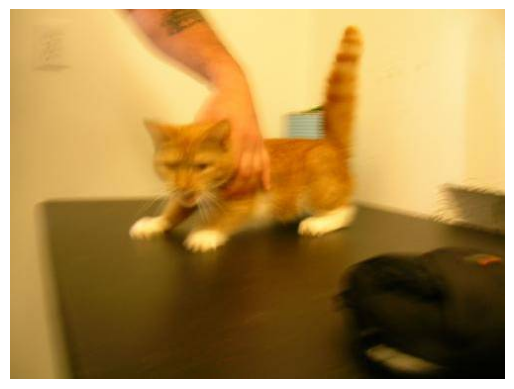

In [ ]:
import cv2
import matplotlib.pyplot as plt

def predict_image(path):

    img = cv2.imread(path)

    img_resized = cv2.resize(img, (64, 64))

    img_flat = img_resized.flatten().reshape(1, -1)

    prediction = model.predict(img_flat)
    if prediction[0] == 0:
        print("It is a Cat ")
    else:
        print("It is a Dog ")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

predict_image("/content/data/train/cat.0.jpg")